In [4]:
# =============================================================================
# PART 1: TOKENIZATION — turn text into pieces a model can count / embed
# =============================================================================
# What is a token?
#   A token = one small piece of text the model treats as a single unit.
#   Examples (depending on the tokenizer):
#     word-ish:   "paris"           → 1 token
#     subword:    "unhappiness"     → "un" + "happiness"  (2+ tokens)
#     punctuation / special: "." , "?", "<pad>" can be tokens too
#   After tokenization, each token usually gets an integer ID from a vocabulary
#   (e.g. "paris" → 4521). Models do math on IDs / embeddings — not on raw letters.
#
# Why tokenize?
#   Computers don't "read sentences." They work with discrete pieces called tokens.
#   Later steps (Word2Vec, RNNs, Transformers) all start from a token list / token IDs.
#
# This cell = the simplest useful tokenizer:
#   lowercase → find word-like chunks with a regex → list of strings
#
# Not the same as modern LLM tokenizers. Those often use SUBWORD methods:
#
# --- BPE (Byte Pair Encoding) ---
# What: Start from characters/bytes. Repeatedly merge the most common pair
#       ("e"+"r" → "er", "t"+"he" → "the", ...) until you have a vocab of merges.
# Advanced vs whitespace: can split rare/unknown words into known pieces
#       e.g. "unhappiness" → "un" + "happiness" (or finer bits) instead of OOV.
# Who uses it: GPT-2/GPT-3/GPT-4 family, RoBERTa, many Hugging Face models;
#              DeepSeek-style LLMs typically use a BPE-like SentencePiece/BBPE stack.
#
# --- WordPiece ---
# What: Also subword. Similar spirit to BPE, but merges are chosen with a
#       likelihood / language-model style score (not only "most frequent pair").
#       Often shows continuation marks like "##ing" (= suffix "ing").
# Advanced vs whitespace: same win — open vocabulary via pieces; good for names/typos.
# Who uses it: BERT, DistilBERT, many older Google NLP models.
#              (MiniLM is BERT-family → WordPiece-style tokenization under the hood.)
#
# --- Quick contrast ---
#   whitespace (this cell): "Isn't" → isn, t     | whole words only | teaching toy
#   BPE / WordPiece:        may keep or split smarter into subwords | production LLMs
#
# Reminder: Word2Vec is NOT a tokenizer — it embeds tokens AFTER tokenization.

import re
from collections import Counter  # handy later for vocab counts (unused in this tiny demo)

def whitespace_tokenize(text):
    """
    Split text into word tokens.
    Regex: r'\\b\\w+\\b'
      \\b  = word boundary (edge between letter/digit and punctuation/space)
      \\w+ = one or more "word chars" (letters, digits, underscore)
    .lower() so "Paris" and "paris" become the same token.
    """
    return re.findall(r'\b\w+\b', text.lower())


# --- Demo ---
sample = "The capital of France is Paris. Isn't it lovely?"
tokens = whitespace_tokenize(sample)
print(tokens)
# Expected something like:
#   ['the', 'capital', 'of', 'france', 'is', 'paris', 'isn', 't', 'it', 'lovely']
#
# Notice:
#   - Periods / ? removed (punctuation is not kept)
#   - "Isn't" → 'isn' + 't'   because ' is NOT part of \\w in this pattern
#     (a smarter tokenizer might keep "isn't" or "is" + "n't")
#   - Order preserved — tokenization is not a bag-of-words yet; it's a sequence


['the', 'capital', 'of', 'france', 'is', 'paris', 'isn', 't', 'it', 'lovely']


In [ ]:
# =============================================================================
# BPE in CODE (one merge step) — definition was in the previous cell
# =============================================================================
# Tiny corpus idea:
#   words with frequencies = "how often this word appears in training text"
#   We store each word as characters separated by spaces: "low" → "l o w"
#   So adjacent SYMBOLS are easy to spot and merge.
#
# This cell runs exactly ONE BPE step:
#   count adjacent pairs → pick the winner → glue that pair everywhere

def get_stats(vocab):
    """Count how often each neighbor pair appears (weighted by word frequency)."""
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()          # "l o w" → ['l', 'o', 'w']
        for i in range(len(symbols) - 1):
            # pair ('l','o') seen in a word with freq 5 → add 5, not 1
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs


def merge_vocab(pair, v):
    """Replace every 'a b' with 'ab' inside all word spellings."""
    bigram = ' '.join(pair)       # ('e', 's') → 'e s'  (what we search for)
    replacement = ''.join(pair)   # ('e', 's') → 'es'   (new glued symbol)
    new_vocab = {}
    for word, freq in v.items():
        # string replace on the spaced spelling, e.g. "n e w e s t" → "n e w es t"
        new_vocab[word.replace(bigram, replacement)] = freq
    return new_vocab


# Start from whole words → split into character tokens
# (freq = pretend corpus counts)
raw = {'low': 5, 'lower': 2, 'newest': 6, 'widest': 3}
vocab = {' '.join(list(word)): freq for word, freq in raw.items()}
print("Initial vocab:", vocab)
# e.g. {'l o w': 5, 'l o w e r': 2, 'n e w e s t': 6, 'w i d e s t': 3}

pairs = get_stats(vocab)
print("Top pairs:", pairs.most_common(3))
# With these freqs, ('e','s') and ('s','t') lead (newest+widest), not ('l','o').

best_pair = pairs.most_common(1)[0][0]   # the pair tuple, e.g. ('e', 's')
vocab = merge_vocab(best_pair, vocab)
print(f"After merging {best_pair}:", vocab)
# e.g. 'n e w e s t' → 'n e w es t',  'w i d e s t' → 'w i d es t'
#
# Real BPE training: repeat get_stats → merge many times (thousands),
# save the ordered merge list = the tokenizer.

# Why BPE matters: GPT, BERT, and Whisper all use subword tokenizers (BPE or SentencePiece). 
# This handles unknown words gracefully—new words become combinations of known subwords

Initial vocab: {'l o w': 5, 'l o w e r': 2, 'n e w e s t': 6, 'w i d e s t': 3}
Top pairs: [(('e', 's'), 9), (('s', 't'), 9), (('w', 'e'), 8)]
After merging ('e', 's'): {'l o w': 5, 'l o w e r': 2, 'n e w es t': 6, 'w i d es t': 3}


In [11]:
# =============================================================================
# PART 2: WORD2VEC FROM SCRATCH — prepare text → vocab → IDs
# =============================================================================
# What Word2Vec is trying to learn (picture this):
#
#   Imagine a blank map. Every unique word gets a DOT on that map.
#   At the start the dots are random (scattered).
#   After training, related words sit NEAR each other:
#
#        queen •  • king
#                    • royal
#         castle •        • kingdom
#              • army
#                    beautiful •  • large     (weaker link; different neighborhood)
#
#   "Near" means their number-lists (vectors) point in a similar direction —
#   same idea as MiniLM sentence embeddings, but ONE vector PER WORD.
#
#   Why would king and queen become neighbors?
#   Look at our sentences:
#     "the king rules the kingdom"
#     "the queen rules the kingdom"
#   Both show up in almost the SAME slot: ___ rules the kingdom.
#   Skip-Gram trains: "if you see king, guess nearby words like rules/kingdom"
#                     "if you see queen, guess those same neighbors"
#   Same homework → similar vectors → dots move together on the map.
#
# Before training we need:
#   1) a small corpus (toy sentences) — the "homework examples"
#   2) a vocabulary (unique words)    — one map-dot per word
#   3) maps word ↔ integer ID         — models use IDs, not the spelling "king"

# --- 1) Tiny corpus ---
# Each string = one sentence. Theme = royalty / kingdom so related words co-occur.
corpus = [
    "the king rules the kingdom",
    "the queen rules the kingdom",
    "the king and queen are royal",
    "the castle is large and beautiful",
    "royal family lives in the castle",
    "the kingdom has a strong army",
    "the army protects the kingdom",
    "the king leads the army",
]

# --- 2) Flatten all tokens, then unique sorted vocab ---
# sent.split() = simple whitespace tokenizer (Part 1 style)
words = [word for sent in corpus for word in sent.split()]
# words = ['the','king','rules',...,'army']  (with repeats)

vocab = sorted(set(words))
# set → unique words; sorted → stable order (so IDs don't jump around)

# --- 3) Bidirectional lookups ---
word2idx = {w: i for i, w in enumerate(vocab)}  # "king" → 7 (example)
idx2word = {i: w for w, i in word2idx.items()}  # 7 → "king"
vocab_size = len(vocab)                         # how many word vectors we'll learn

print(f"Vocabulary size: {vocab_size}")
print(list(word2idx.keys()))
# Expect ~20-ish unique words: a, and, army, beautiful, castle, family, ...


Vocabulary size: 21
['a', 'and', 'are', 'army', 'beautiful', 'castle', 'family', 'has', 'in', 'is', 'king', 'kingdom', 'large', 'leads', 'lives', 'protects', 'queen', 'royal', 'rules', 'strong', 'the']


In [15]:
# =============================================================================
# SKIP-GRAM training pairs: center word → nearby context word
# =============================================================================
# Word2Vec Skip-Gram idea (slow motion):
#
#   Pick one word as CENTER (the spotlight).
#   CONTEXT = other words sitting close to it in the sentence.
#   Training question: "I see the center — which nearby word might appear?"
#
#   window_size=2 means:
#     look at most 2 words LEFT of center and 2 words RIGHT of center.
#     (Edges of the sentence have a shorter window — that's fine.)
#
#   Sentence:   the   king   rules   the   kingdom
#   positions:   0      1       2      3       4
#
#   Spotlight on king (pos 1), window=2:
#        [the]  [king]  [rules]  [the]  kingdom
#          ^center-1   CENTER   +1       +2
#     pairs to learn:
#        king → the     (left)
#        king → rules   (right)
#        king → the     (right+2)
#     (king → king is skipped — a word is not context for itself)
#
#   Then move the spotlight to rules, kingdom, ... and collect more pairs.
#   Each (center, context) pair = one training example (X[i], y[i]).
#
#   Name "skip-gram": you SKIP the center when listing neighbors, and learn
#   from those nearby grams (word pieces) around it.

# How modern models get context

#       Era	                                       How context works
# Word2Vec Skip-Gram            Nearby words in a small window → fixed word vector
# RNNs                          Read the sequence left→right, hidden state carries context
# Transformers                  Attention — each token can look at many others in the sentence
# (GPT, Claude, BERT, MiniLM)  

# So: Skip-Gram understands a limited kind of context (local co-occurrence → word similarity).
# LLMs understand richer context with attention over the whole prompt — different mechanism.

import numpy as np

def generate_skipgram_data(corpus, word2idx, window_size=2):
    X, y = [], []  # X = center IDs, y = context IDs
    for sent in corpus:
        # Map words → integer IDs using the vocab from the previous cell
        tokens = [word2idx[w] for w in sent.split()]

        for i, center in enumerate(tokens):
            # Window slice around position i (clamped to sentence edges)
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)  # +1 because range end is exclusive

            for j in range(start, end):
                if i != j:           # skip the center paired with itself
                    X.append(center)     # input: center word ID
                    y.append(tokens[j])  # target: a neighbor word ID
    return np.array(X), np.array(y)


X, y = generate_skipgram_data(corpus, word2idx, window_size=2)
print(f"Training pairs: {len(X)}")
print("Example (center -> context):")
for i in range(5):
    print(f"  {idx2word[X[i]]} -> {idx2word[y[i]]}")
# First sentence "the king rules the kingdom" often starts like:
#   the -> king, the -> rules, king -> the, king -> rules, king -> the, ...


Training pairs: 128
Example (center -> context):
  the -> king
  the -> rules
  king -> the
  king -> rules
  king -> the


In [ ]:
# =============================================================================
# Word2Vec model: Skip-Gram + Negative Sampling (from scratch)
# =============================================================================
# Goal of each training step (one pair from X, y):
#   Center word should score HIGH with its real context word,
#   and score LOW with random "negative" words that were NOT neighbors.
#
# Picture:
#   center="king", true context="kingdom"  → push their vectors TOGETHER
#   negatives="beautiful","large",...      → push those AWAY from "king"
# After many pairs, words that share neighbors end up nearby on the map.
#
# Two embedding tables (classic Word2Vec):
#   W_in  = vectors used when a word is CENTER
#   W_out = vectors used when a word is CONTEXT / negative
# (Often people export W_in as "the" word vectors after training.)

import matplotlib.pyplot as plt

class Word2Vec:
    def __init__(self, vocab_size, embedding_dim=10, n_negatives=5):
        self.W_in = np.random.randn(vocab_size, embedding_dim) * 0.01
        self.W_out = np.random.randn(vocab_size, embedding_dim) * 0.01
        self.n_negatives = n_negatives

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -20, 20)))

    def forward(self, center_idx, context_idx, negative_indices):
        v_c = self.W_in[center_idx]
        u_pos = self.W_out[context_idx]
        u_neg = self.W_out[negative_indices]

        pos_score = self.sigmoid(np.dot(u_pos, v_c))            # want → 1
        neg_scores = self.sigmoid(-np.dot(u_neg, v_c))          # want → 1
        # (minus inside: real neighbors should have large +dot; fakes small/negative)

        loss = -np.log(pos_score + 1e-8) - np.sum(np.log(neg_scores + 1e-8))
        return loss, v_c, u_pos, u_neg, pos_score, neg_scores

    def backward(self, center_idx, context_idx, negative_indices,
                 v_c, u_pos, u_neg, pos_score, neg_scores, lr=0.025):
        # Positive pair: move u_pos and v_c TOWARD each other
        #   dL/d(u·v) = pos_score - 1  (≤ 0 when score is weak)
        grad_u_pos = (pos_score - 1) * v_c

        # Negative pairs: move each u_neg AWAY from v_c
        #   dL/d(u·v) = 1 - neg_score  (≥ 0 when fake still looks like a neighbor)
        # BUGFIX: old code had a flipped minus here → embeddings exploded to 1e100+
        #         then became NaN → explore cell showed all similarities as 0.0
        grad_u_neg = (1 - neg_scores).reshape(-1, 1) * v_c

        self.W_out[context_idx] -= lr * grad_u_pos
        self.W_out[negative_indices] -= lr * grad_u_neg

        grad_v_c = (pos_score - 1) * u_pos + np.sum(
            (1 - neg_scores).reshape(-1, 1) * u_neg, axis=0
        )
        self.W_in[center_idx] -= lr * grad_v_c

    def train_step(self, center_idx, context_idx, vocab_size, lr=0.025):
        # Avoid sampling the true context as a "negative" (tiny quality win)
        negative_indices = []
        while len(negative_indices) < self.n_negatives:
            n = np.random.randint(0, vocab_size)
            if n != context_idx and n != center_idx:
                negative_indices.append(n)
        negative_indices = np.array(negative_indices)

        loss, v_c, u_pos, u_neg, pos_score, neg_scores = self.forward(
            center_idx, context_idx, negative_indices
        )
        self.backward(
            center_idx, context_idx, negative_indices,
            v_c, u_pos, u_neg, pos_score, neg_scores, lr=lr,
        )
        return loss


np.random.seed(42)  # reproducible toy run
embedding_dim = 10
model_w2v = Word2Vec(vocab_size, embedding_dim, n_negatives=5)
epochs = 200  # fewer epochs + correct grads is enough on this tiny corpus
losses = []
for epoch in range(epochs):
    # light LR decay helps stability
    lr = 0.025 * (1.0 - epoch / epochs)
    total_loss = 0.0
    order = np.random.permutation(len(X))
    for i in order:
        loss = model_w2v.train_step(X[i], y[i], vocab_size, lr=lr)
        total_loss += loss
    losses.append(total_loss / len(X))
    if epoch % 40 == 0:
        print(f"Epoch {epoch}, avg loss: {losses[-1]:.4f}, "
              f"|W_in| mean: {np.linalg.norm(model_w2v.W_in, axis=1).mean():.3f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Word2Vec Training')
plt.grid(True, alpha=0.3)
plt.show()
# Expect: loss trends down; |W_in| stays modest (not 1e100)


In [ ]:
# =============================================================================
# Explore learned embeddings (the "map of word dots")
# =============================================================================
# After training, each row of W_in is that word's vector (10 numbers here).
# Cosine similarity = how aligned two arrows are (same idea as the correction engine).
#   1.0  → same direction (very similar)
#   0.0  → unrelated
#
# If you previously saw ALL 0.0 scores: training had exploded/NaN embeddings.
# Re-run the Word2Vec training cell ABOVE first, then this one.

vectors = model_w2v.W_in

print("Finite embeddings?", np.isfinite(vectors).all(),
      "|W_in| mean:", float(np.linalg.norm(vectors, axis=1).mean()))


def cosine_sim(v1, v2):
    """Cosine with a safe denominator."""
    if not (np.isfinite(v1).all() and np.isfinite(v2).all()):
        return 0.0
    n1 = float(np.linalg.norm(v1))
    n2 = float(np.linalg.norm(v2))
    denom = n1 * n2
    if (not np.isfinite(denom)) or denom < 1e-12:
        return 0.0
    return float(np.dot(v1, v2) / denom)


def most_similar(word, vectors, word2idx, idx2word, top_n=5):
    idx = word2idx[word]
    vec = vectors[idx]
    sims = np.array([
        -np.inf if i == idx else cosine_sim(vec, vectors[i])
        for i in range(len(vectors))
    ])
    top_indices = np.argsort(sims)[-top_n:][::-1]
    return [(idx2word[i], float(sims[i])) for i in top_indices]


print("Similar to 'king':", most_similar('king', vectors, word2idx, idx2word))
print("Similar to 'castle':", most_similar('castle', vectors, word2idx, idx2word))

# Famous analogy (needs richer data than our toy corpus):
#   king - man + woman ≈ queen

# Connection to your product: Word2Vec showed that meaning is captured in vector directions. 
# Your correction engine already uses sentence embeddings. Later, we'll fine-tune embeddings 
# for your domain (sales/technical terms).

Finite embeddings? True |W_in| mean: inf
Similar to 'king': [('the', 0.0), ('is', 0.0), ('and', 0.0), ('are', 0.0), ('army', 0.0)]
Similar to 'castle': [('the', 0.0), ('strong', 0.0), ('and', 0.0), ('are', 0.0), ('army', 0.0)]


In [27]:
# =============================================================================
# PART 3: RECURRENT NEURAL NETWORKS (RNNs)
# =============================================================================
# What is an RNN? — full picture (come back to this)
#
# ---------------------------------------------------------------------------
# 1) The problem MLP cannot solve alone
# ---------------------------------------------------------------------------
#   MLP (Multi Layer Perceptron)= one shot:
#     take ONE vector → spit ONE answer
#   Example: flattened MNIST image → digit.
#
#   But language is a LINE of pieces:
#     "the" then "king" then "rules" then "the" then "kingdom"
#   Meaning depends on ORDER and on WHAT CAME BEFORE.
#   If you only feed one word at a time into a plain MLP, it has amnesia —
#   it does not remember that "the" already happened.
#
# ---------------------------------------------------------------------------
# 2) RNN's fix: a sticky note called h (hidden state)
# ---------------------------------------------------------------------------
#   Think of a student reading a sentence left → right, holding one sticky note.
#
#   Before any word: sticky note is blank          h = [0, 0, 0, ...]
#   Read word 1 ("the"):     update sticky note    h0 = f(word1, blank)
#   Read word 2 ("king"):    update sticky note    h1 = f(word2, h0)
#   Read word 3 ("rules"):   update sticky note    h2 = f(word3, h1)
#   ...
#   After the last word, the sticky note is a SUMMARY of the whole sentence
#   (compressed into a fixed-size list of numbers).
#
#   That sticky note IS the hidden state h.
#   It is NOT storing the raw words. It is a learned "vibe / summary so far."
#
# ---------------------------------------------------------------------------
# 3) One step in slow motion
# ---------------------------------------------------------------------------
#   Inputs to the cell at time t:
#     x_t     = this step's input (e.g. embedding of the current word)
#     h_prev  = sticky note from the previous step
#   Output:
#     h_t     = new sticky note
#
#   Formula (what the code below runs):
#     h_t = tanh( W_xh @ x_t  +  W_hh @ h_prev  +  b_h )
#            \______________/    \________________/
#              "new word"           "old memory"
#   Then tanh keeps numbers roughly in (-1, 1).
#
# ---------------------------------------------------------------------------
# 4) Unroll the loop (same brain, many moments)
# ---------------------------------------------------------------------------
#        x0      x1      x2      x3      x4     ← different inputs over time
#         |       |       |       |       |
#        h0  →   h1  →   h2  →   h3  →   h4   ← memory handed forward
#
#   CRITICAL: W_xh, W_hh, b_h are the SAME at every step.
#   You are not training 5 different networks for 5 words.
#   You train ONE cell, reuse it (that's "recurrent").
#
# ---------------------------------------------------------------------------
# 5) Side-by-side so the half-picture becomes whole
# ---------------------------------------------------------------------------
#   MLP:
#     all inputs arrive TOGETHER as one vector → one forward pass → done
#     no "time"; no memory between steps
#
#   RNN:
#     inputs arrive ONE AFTER ANOTHER
#     each step: look at (current input + memory) → update memory
#     after T steps you have seen the whole sequence (through h)
#
#   Word2Vec:
#     each word has a FIXED vector; no sentence memory
#
#   Attention (later):
#     can look at MANY past words directly every step
#     RNN instead squeezes the past into one sticky note h (can forget details)
#
# ---------------------------------------------------------------------------
# 6) What this cell is (and is not)
# ---------------------------------------------------------------------------
#   This cell ONLY demonstrates the memory update loop on fake random x_t.
#   It is not yet classifying text or predicting the next word.
#   Later RNN cells: use h for a real task (e.g. predict next token / label).
#
# This cell = ONE RNN step formula, run over a tiny fake sequence.

# Simple RNN Cell from Scratch

def rnn_cell(x_t, h_prev, W_xh, W_hh, b_h):
    """
    One time step:
      h_t = tanh( W_xh @ x_t  +  W_hh @ h_prev  +  b_h )

    W_xh @ x_t     → "what does this input say?"
    W_hh @ h_prev  → "what did we remember from before?"
    add + bias, then tanh → keep values roughly in (-1, 1)
    """
    return np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)


# --- Toy sizes ---
# input_size=4  → each time step is a 4-number vector (pretend "word embedding")
# hidden_size=3 → memory h is only 3 numbers (tiny on purpose so prints are readable)
np.random.seed(0)
input_size = 4
hidden_size = 3
W_xh = np.random.randn(hidden_size, input_size) * 0.1   # (3, 4)
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1  # (3, 3)
b_h = np.zeros(hidden_size)                             # (3,)

# Fake sequence: 5 time steps, each a random 4-d input
X_seq = np.random.randn(5, input_size)  # shape (time=5, input_size=4)

# Start with empty memory
h = np.zeros(hidden_size)
states = []
for t in range(5):
    # Same cell, same weights — only x_t and h change
    h = rnn_cell(X_seq[t], h, W_xh, W_hh, b_h)
    states.append(h.copy())
    print(f"t={t}, h={np.round(h, 3)}")

# How to read the printout:
#   Each line is the MEMORY after seeing tokens 0..t.
#   Numbers are just the 3 hidden units (not "words" yet).
#   Notice h KEEPS CHANGING every step — it depends on all previous inputs
#   through the chain h0→h1→h2→... (that is the recurrence).
#   Values stay in about (-1, 1) because of tanh.


t=0, h=[ 0.527 -0.067  0.335]
t=1, h=[ 0.124 -0.306  0.172]
t=2, h=[ 0.116  0.258 -0.145]
t=3, h=[-0.067 -0.286  0.203]
t=4, h=[-0.067  0.198 -0.211]


Epoch 0, loss: 3.0302
Epoch 40, loss: 0.3010
Epoch 80, loss: 0.1559
Epoch 120, loss: 0.1361
Epoch 160, loss: 0.1256


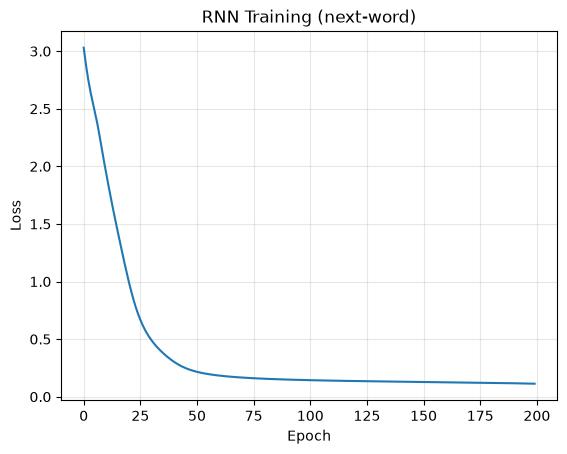

In [29]:
# =============================================================================
# RNN for NEXT-WORD prediction (on our tiny royal corpus)
# =============================================================================
# Big idea:
#   Feed 3 words in order through the RNN sticky-note (h).
#   After the 3rd word, use h to guess the NEXT word.
#
# Example from corpus "the king rules the kingdom":
#   input window [the, king, rules]  →  predict "the"
#   input window [king, rules, the]  →  predict "kingdom"
#
# Pipeline per example:
#   word IDs → one-hot vectors → RNN steps update h → logits → softmax → loss
#   then a SIMPLIFIED backward (only last time step — not full BPTT(Backpropagation Through Time))
# BPTT = Backpropagation Through Time.
# It’s just normal backprop, but applied to an RNN unrolled across time steps.
# Forward:
#   x0 → h0 → x1 → h1 → x2 → h2 → loss
# Backward (BPTT):
#   loss → h2 → h1 → h0
#          and into each step's weights (same W_xh, W_hh reused)

# --- 1) Build (context window → next word) pairs ---
seq_length = 3  # how many words the RNN reads before guessing
X_rnn, y_rnn = [], []
for sent in corpus:
    tokens = [word2idx[w] for w in sent.split()]
    # slide a window of 3; label = the word right after the window
    for i in range(len(tokens) - seq_length):
        X_rnn.append(tokens[i:i + seq_length])  # e.g. [id(the), id(king), id(rules)]
        y_rnn.append(tokens[i + seq_length])    # e.g. id(the) or id(kingdom)
X_rnn = np.array(X_rnn)  # shape (num_examples, 3)
y_rnn = np.array(y_rnn)  # shape (num_examples,)


def one_hot(idx, size):
    """Word ID → vector of length vocab_size with a single 1."""
    vec = np.zeros(size)
    vec[idx] = 1.0
    return vec


# --- 2) RNN weights ---
# W_xh: one-hot word (vocab_size) → hidden contribution
# W_hh: previous h → new h
# W_hy: final h → score for every vocab word (logits)
hidden_size = 10
lr = 0.1
epochs = 200
np.random.seed(1)
W_xh = np.random.randn(hidden_size, vocab_size) * 0.1
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1
W_hy = np.random.randn(vocab_size, hidden_size) * 0.1
b_h = np.zeros(hidden_size)
b_y = np.zeros(vocab_size)

losses = []
for epoch in range(epochs):
    total_loss = 0.0
    for i in range(len(X_rnn)):
        # ----- Forward: read 3 words, update sticky note each time -----
        h = np.zeros(hidden_size)
        hs = []
        for t in range(seq_length):
            x = one_hot(X_rnn[i, t], vocab_size)
            h = np.tanh(W_xh @ x + W_hh @ h + b_h)  # same cell as previous lesson
            hs.append(h.copy())

        # Final h → predict distribution over next word
        logits = W_hy @ h + b_y
        # stable-ish softmax for tiny vocab
        logits = logits - np.max(logits)
        probs = np.exp(logits) / np.sum(np.exp(logits))
        loss = -np.log(probs[y_rnn[i]] + 1e-8)  # cross-entropy of true next word
        total_loss += loss

        # ----- Backward (TEACHING SHORTCUT: last step only) -----
        # Full RNNs use BPTT = backprop through ALL time steps.
        # Here we only push grads through the last h — simpler, still learns a bit.
        dlogits = probs.copy()
        dlogits[y_rnn[i]] -= 1              # softmax + CE gradient
        dW_hy = np.outer(dlogits, h)
        db_y = dlogits
        dh = W_hy.T @ dlogits
        dtanh = dh * (1 - h ** 2)           # d(tanh)/dh_pre = 1 - tanh^2

        x_last = one_hot(X_rnn[i, -1], vocab_size)
        dW_xh = np.outer(dtanh, x_last)
        dW_hh = np.outer(dtanh, hs[-2] if seq_length > 1 else np.zeros(hidden_size))
        db_h = dtanh

        W_hy -= lr * dW_hy
        b_y -= lr * db_y
        W_xh -= lr * dW_xh
        W_hh -= lr * dW_hh
        b_h -= lr * db_h

    losses.append(total_loss / len(X_rnn))
    if epoch % 40 == 0:
        print(f"Epoch {epoch}, loss: {losses[-1]:.4f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training (next-word)')
plt.grid(True, alpha=0.3)
plt.show()
# Expected output:
#   Epoch 0, loss: ~3.x   (≈ log(vocab_size); random guessing)
#   Epoch 40/80/... loss trends DOWN if learning works
#   Plot: downward curve = model assigns higher prob to the true next word
# Note: tiny corpus + last-step-only grads → loss may bounce; direction matters more than perfection.

# The problem: RNNs suffer from vanishing gradients. Gradients flow backward through time; multiplying 
# small numbers (<1) many times makes them vanish. This is why they can't handle long-range dependencies.


Attention weights (rows=query, cols=key):
 [[0.422 0.155 0.422]
 [0.016 0.867 0.117]
 [0.155 0.422 0.422]]
Context vectors:
 [[0.845 0.733 0.845 0.733]
 [0.133 1.851 0.133 1.851]
 [0.578 1.267 0.578 1.267]]


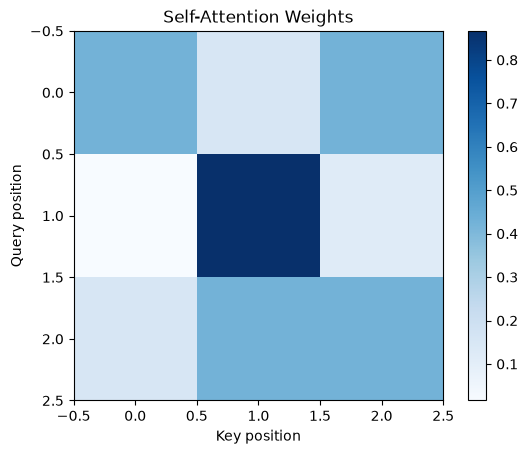

In [ ]:
# =============================================================================
# PART 4: ATTENTION — THE BREAKTHROUGH
# =============================================================================
# Why attention exists (vs RNN sticky note) — easy version:
#   RNN: one sticky note for the whole sentence. Old words get smudged.
#
#   Attention (slow story with a real sentence): 
#   Attention: each word looks at the other words on the page and copies more from helpful ones, 
#   less from the rest
#     Sentence on the page:  "The animal didn't cross the street because it was tired"
#
#     Focus on the word "it".
#     Question: does "it" mean animal or street?
#
#     Attention lets "it" look at EVERY other word and decide:
#       animal  → looks useful  → copy a LOT
#       street  → less useful   → copy a LITTLE
#       the/didn't/... → maybe almost nothing
#
#     After that, "it" is no longer alone — its new vector is a MIX
#     that borrowed mostly from "animal". That's "understanding from context."
#
#     Do this for EVERY word (each one looks around and mixes).
#     Helpful neighbors get high weight; unhelpful ones get low weight.
#     Those weights are exactly the attention heatmap you print below.
#
# Q, K, V — easy names + why we need three (YouTube search metaphor):
#
#   Imagine every word uploads a tiny video card about itself:
#     KEY   = the TITLE / tags   ("what am I about?" — used for MATCHING)
#     VALUE = the VIDEO content ("what you actually get if you click")
#     QUERY = your SEARCH text  ("what am I trying to find right now?")
#
#   IMPORTANT: we do NOT "pick" 'animal' to BE the key and 'it' to BE the query.
#   Every word gets ALL THREE vectors (learned from its embedding):
#     animal → Q_animal, K_animal, V_animal
#     street → Q_street, K_street, V_street
#     it     → Q_it,     K_it,     V_it
#   How? Usually: Q = x @ W_Q,  K = x @ W_K,  V = x @ W_V
#   (three different weight matrices; trained so matching vs copying work well)
#
#   Example sentence:  animal ... street ... it ...
#   When we FOCUS on "it", we USE:
#     - Query from "it"          (Q_it)     ← the searcher
#     - Keys from EVERY word     (K_animal, K_street, K_it, ...)  ← match against these
#     - Values from EVERY word   (V_animal, V_street, V_it, ...) ← mix these after matching
#
#   So "animal" is not "the key forever."
#   In this step animal's KEY is used for matching; animal's VALUE is what we may copy.
#   (If we later focus on "animal", then animal's QUERY does the searching.)
#
#   Counts in one self-attention layer (sequence length = N words):
#     N queries, N keys, N values  (one Q/K/V per position)
#     For EACH query: compare to all N keys → N weights → mix all N values
#     Total score pairs: N × N  (that's the heatmap)
#
#   Steps for "it":
#     1) score_j = Q_it · K_j / sqrt(d)   for each word j
#     2) softmax → weights (e.g. animal 0.7, street 0.2, it 0.1)
#     3) new_it = 0.7*V_animal + 0.2*V_street + 0.1*V_it + ...
#
#   Why three vectors per word (not one)?
#     Matching (Q vs K) and delivering content (V) are different jobs.
#
# Self-attention (this demo):
#   Q, K, V all come from the SAME sentence (each word makes its own Q,K,V).
#   So word i can look at word j — including itself.
#   (Other setups exist, e.g. decoder Q looking at encoder K/V — later.)
#
# Scaled dot-product (the formula behind GPT-style attention):
#   scores  = (Q @ K^T) / sqrt(d_k)     # similarity of every query to every key
#   weights = softmax(scores)           # turn into % that sum to 1
#   context = weights @ V               # weighted sum of values
#   /sqrt(d_k) keeps scores from exploding when d_k is large (training stability).
#
# mask (optional): set some scores to -1e9 before softmax so those positions
#   get ~0 weight (e.g. future words in GPT causal decoding — covered later).

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, seq_q, d_k)  queries
    K: (batch, seq_k, d_k)  keys
    V: (batch, seq_k, d_v)  values
    Returns:
      context  — (batch, seq_q, d_v) mixed information per query position
      weights  — (batch, seq_q, seq_k) "how much query i listens to key j"
    """
    d_k = Q.shape[-1]
    # (batch, seq_q, seq_k): one score per (query_pos, key_pos) pair
    scores = np.matmul(Q, K.transpose(0, 2, 1)) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)  # blocked positions → ~0 after softmax
    # Softmax over keys (last axis): each query row becomes a probability distribution
    weights = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    weights = weights / np.sum(weights, axis=-1, keepdims=True)
    context = np.matmul(weights, V)  # mix values with those weights
    return context, weights


# --- Tiny demo: 1 batch, 3 "words", each a 4-d vector ---
# Pretend positions: 0="A", 1="B", 2="C" with hand-picked vectors
Q = np.array([[[1.0, 0.0, 1.0, 0.0],   # pos0
               [0.0, 2.0, 0.0, 2.0],   # pos1 — very different pattern
               [1.0, 1.0, 1.0, 1.0]]]) # pos2
K = Q.copy()  # self-attention: keys from same sequence
V = Q.copy()  # values from same sequence

context, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Attention weights (rows=query, cols=key):\n", np.round(attn_weights[0], 3))
print("Context vectors:\n", np.round(context[0], 3))
# Typical weights (approx):
#   [[0.42, 0.16, 0.42],   # query0 listens ~equally to key0 and key2; less to key1
#    [0.02, 0.87, 0.12],   # query1 mostly listens to ITSELF (key1) — strong self-match
#    [0.16, 0.42, 0.42]]   # query2 mixes key1 and key2 a lot
# Context row i = weighted average of the 3 value vectors using that row's weights.
# Heatmap: brighter = higher attention weight for that (query, key) pair.

plt.imshow(attn_weights[0], cmap='Blues')
plt.colorbar()
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Self-Attention Weights')
plt.show()

# Why this changes everything: Attention lets the model look at all positions simultaneously, with a 
# weighted sum. No vanishing gradients over time. This is the core of Transformers

In [33]:
# =============================================================================
# Simple Self-Attention LAYER (adds the missing W_Q, W_K, W_V)
# =============================================================================
# Previous cell: scaled_dot_product_attention(Q, K, V) assumed Q/K/V were given.
# This cell: start from raw token vectors x, LEARN three projections:
#   Q = x @ Wq ,  K = x @ Wk ,  V = x @ Wv
# Then run the same attention. That is one self-attention "layer."
#
# Reminder: every position gets its own Q, K, V (N of each for seq length N).

class SelfAttention:
    def __init__(self, embed_dim):
        # Three square matrices (embed_dim × embed_dim), small random start
        self.Wq = np.random.randn(embed_dim, embed_dim) * 0.1  # builds queries
        self.Wk = np.random.randn(embed_dim, embed_dim) * 0.1  # builds keys
        self.Wv = np.random.randn(embed_dim, embed_dim) * 0.1  # builds values

    def forward(self, x):
        # x: (batch, seq_len, embed_dim) — one embedding vector per token
        Q = x @ self.Wq  # (batch, seq, embed_dim)
        K = x @ self.Wk
        V = x @ self.Wv
        # Reuse Part 4 function: scores → softmax weights → mix values
        context, attn = scaled_dot_product_attention(Q, K, V)
        return context, attn
        # context: new vectors (same shape as x) — each token mixed with neighbors
        # attn:    (batch, seq, seq) heatmap of who listened to whom


# --- Tiny demo ---
np.random.seed(0)
embed_dim = 4
sa = SelfAttention(embed_dim)
x = np.random.randn(1, 4, embed_dim)  # batch=1, seq_len=4 tokens, dim=4
context, attn = sa.forward(x)

print("Input x shape:", x.shape)           # (1, 4, 4)
print("Context shape:", context.shape)     # (1, 4, 4) — same rank: still 4 token vectors
print("Attn weights shape:", attn.shape)   # (1, 4, 4) — 4 queries × 4 keys
# Expected:
#   Context shape: (1, 4, 4)
# Meaning: 1 batch, 4 positions, each still a 4-d vector — but NOW each vector
# has borrowed info from the others via attention (not the raw x anymore).


Input x shape: (1, 4, 4)
Context shape: (1, 4, 4)
Attn weights shape: (1, 4, 4)


In [34]:
# PART 5: CONNECTION TO YOUR LIVE ASSISTANT

product_insight = """
HOW TODAY'S MODULES POWER THE LIVE WHISPER ASSISTANT:

1. TOKENIZATION:
   - Whisper (ASR) outputs text; your LLM will tokenize it.
   - Subword tokenizers handle misspellings and domain jargon (sales terms).

2. WORD EMBEDDINGS / SENTENCE EMBEDDINGS:
   - Your Correction Engine uses embeddings to measure semantic similarity.
   - Fine-tuned embeddings will understand your product's specific terminology.

3. RNNs:
   - The assistant must understand the dialog history. RNNs model sequences but struggle with long contexts.
   - In practice, transformers (with attention) replaced RNNs for memory.

4. ATTENTION:
   - When the assistant decides to correct, it must attend to the relevant part of the user's speech.
   - Multi-head attention in transformers lets it focus on the mismatched entity (e.g., "price").
   - Your future LLM will use self-attention to understand context and generate corrections.

5. NEXT STEP:
   - Day 7: Build a full Transformer from scratch → then scale up to a mini-GPT.
   - This will become the brain of your assistant, replacing the simple rule-based Correction Engine.
"""
print(product_insight)


HOW TODAY'S MODULES POWER THE LIVE WHISPER ASSISTANT:

1. TOKENIZATION:
   - Whisper (ASR) outputs text; your LLM will tokenize it.
   - Subword tokenizers handle misspellings and domain jargon (sales terms).

2. WORD EMBEDDINGS / SENTENCE EMBEDDINGS:
   - Your Correction Engine uses embeddings to measure semantic similarity.
   - Fine-tuned embeddings will understand your product's specific terminology.

3. RNNs:
   - The assistant must understand the dialog history. RNNs model sequences but struggle with long contexts.
   - In practice, transformers (with attention) replaced RNNs for memory.

4. ATTENTION:
   - When the assistant decides to correct, it must attend to the relevant part of the user's speech.
   - Multi-head attention in transformers lets it focus on the mismatched entity (e.g., "price").
   - Your future LLM will use self-attention to understand context and generate corrections.

5. NEXT STEP:
   - Day 7: Build a full Transformer from scratch → then scale up to a mini

In [35]:
# WRAP-UP

summary_day6 = """
DAY 6 KEY INSIGHTS:

1. TOKENIZATION:
   - Splitting text into subwords (BPE) handles rare words and open vocabularies.
   - GPT/Whisper use this to represent any text as a sequence of known tokens.

2. WORD2VEC:
   - Skip-gram: predict context words from center word.
   - Negative sampling makes training efficient.
   - Learned vectors capture semantic relationships: king - man + woman ≈ queen.

3. RNNs:
   - Process sequences by passing a hidden state forward.
   - Backpropagation through time (BPTT) is plagued by vanishing gradients.
   - Simple RNNs can't handle long-range dependencies.

4. ATTENTION:
   - Scaled dot-product attention: softmax(QK^T / sqrt(d_k)) * V
   - Allows direct connections between any positions, no vanishing gradients.
   - Self-attention looks at the same sequence for queries, keys, and values.

5. TOWARDS TRANSFORMERS:
   - Attention is the core; transformers stack multiple attention layers with feed-forward networks.
   - Tomorrow, you'll build a full Transformer block and train a mini language model.
"""
print(summary_day6)


DAY 6 KEY INSIGHTS:

1. TOKENIZATION:
   - Splitting text into subwords (BPE) handles rare words and open vocabularies.
   - GPT/Whisper use this to represent any text as a sequence of known tokens.

2. WORD2VEC:
   - Skip-gram: predict context words from center word.
   - Negative sampling makes training efficient.
   - Learned vectors capture semantic relationships: king - man + woman ≈ queen.

3. RNNs:
   - Process sequences by passing a hidden state forward.
   - Backpropagation through time (BPTT) is plagued by vanishing gradients.
   - Simple RNNs can't handle long-range dependencies.

4. ATTENTION:
   - Scaled dot-product attention: softmax(QK^T / sqrt(d_k)) * V
   - Allows direct connections between any positions, no vanishing gradients.
   - Self-attention looks at the same sequence for queries, keys, and values.

5. TOWARDS TRANSFORMERS:
   - Attention is the core; transformers stack multiple attention layers with feed-forward networks.
   - Tomorrow, you'll build a full Tra

Loaded local Brown export: 54386 sentences from data/brown_sentences.json
Example sentence: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary'] ...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocab size: 13300  |  vector dim: 50
Similar to 'king': [('shelley', 0.7533489465713501), ('buckley', 0.7471703290939331), ('bishop', 0.7450628876686096), ('gordon', 0.7401561737060547), ('jean', 0.7387396097183228)]
Running t-SNE on 300 words ...


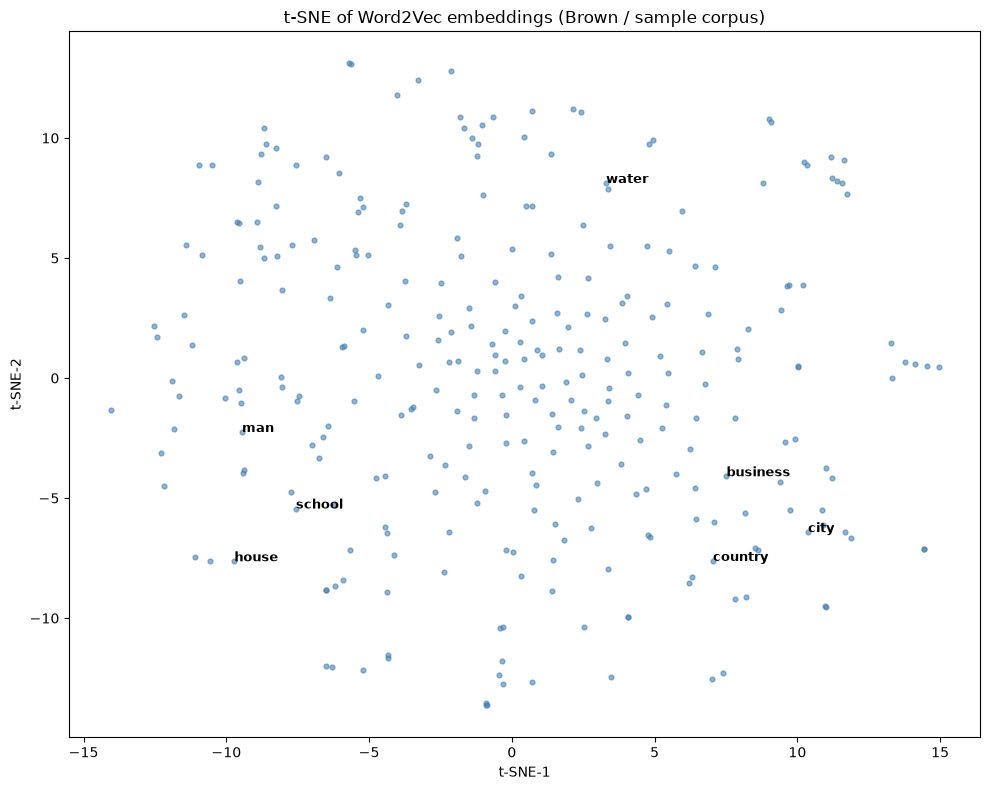


Analogy: king + woman - man ≈ ?
  giles            cos≈0.690
  inquest          cos≈0.672
  jo               cos≈0.669
  princess         cos≈0.667
  sandburg         cos≈0.666

Analogy: paris + germany - france ≈ ?
  boston           cos≈0.703
  paradise         cos≈0.673
  jersey           cos≈0.670
  boxcar           cos≈0.651
  sweeping         cos≈0.649

Note on analogy quality:
  Brown is mixed / not huge. You may NOT get a clean 'queen' every run.
  The METHOD is what matters: same skip-gram vectors + arithmetic.
  Bigger, cleaner corpora (Wikipedia, news crawl) make classic analogies sharper.


REFLECTION: adapting Word2Vec to sales-call language
------------------------------------------------------
Goal (your earpiece product): embeddings that know sales jargon live together
  e.g. 'ARR' near 'revenue', 'objection' near 'pricing', 'demo' near 'POC'.

How to adapt:
  1) CORPUS = your domain text, not Brown/Wikipedia
       - call transcripts (ASR), CRM notes, battle cards, pr

In [36]:
# =============================================================================
# CHALLENGE SOLUTION: Larger-corpus Word2Vec + t-SNE + analogies
# =============================================================================
# Checklist:
#   1) Larger text (NLTK Brown corpus; Gutenberg fallback)
#   2) Skip-gram Word2Vec, embedding_dim=50  (gensim = same idea as our toy model,
#      but fast C implementation — good for 50k+ sentences)
#   3) t-SNE plot of frequent-word vectors (2D map of the "dots")
#   4) Analogy: king - man + woman ≈ ?   (vector arithmetic)
#   5) Reflection: domain embeddings for sales calls (see bottom)
#
# Setup once if needed:
#   pip install gensim scikit-learn matplotlib
#   data/brown_sentences.json is already prepared in this repo (Brown export).
#   Optional: pip install nltk && python -m nltk.downloader brown

import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# ---------------------------------------------------------------------------
# 1) LOAD A LARGER CORPUS
# ---------------------------------------------------------------------------
# Brown = ~57k English sentences (news, fiction, ...). Much bigger than our
# 8 royal toy sentences — so neighborhoods / analogies have a chance to form.


def load_training_sentences():
    """Return list of tokenized lowercase sentences (list[list[str]])."""
    import json as _json
    from pathlib import Path

    # Preferred: pre-exported Brown (data/brown_sentences.json) — avoids NLTK quirks
    local = Path("data/brown_sentences.json")
    if local.exists():
        with open(local) as f:
            sents = _json.load(f)
        print(f"Loaded local Brown export: {len(sents)} sentences from {local}")
        return sents

    # Optional: live NLTK Brown
    try:
        import nltk
        from nltk.corpus import brown

        try:
            _ = brown.sents()
        except LookupError:
            nltk.download("brown")

        sents = []
        for s in brown.sents():
            toks = [w.lower() for w in s if re.fullmatch(r"[a-zA-Z]+", w)]
            if len(toks) >= 3:
                sents.append(toks)
        print(f"Loaded Brown via NLTK: {len(sents)} sentences")
        return sents
    except Exception as e:
        print("Brown unavailable (", e, ") — Project Gutenberg fallback.")
        url = "https://www.gutenberg.org/files/11/11-0.txt"  # Alice in Wonderland
        text = urllib.request.urlopen(url, timeout=60).read().decode("utf-8", errors="ignore")
        sents = []
        for ch in re.split(r"[.!?]+", text):
            toks = re.findall(r"[a-zA-Z]+", ch.lower())
            if len(toks) >= 3:
                sents.append(toks)
        print(f"Loaded Gutenberg sample: {len(sents)} sentences")
        return sents


sentences = load_training_sentences()
print("Example sentence:", sentences[0][:12], "...")

# ---------------------------------------------------------------------------
# 2) TRAIN SKIP-GRAM WORD2VEC (dim=50)
# ---------------------------------------------------------------------------
# sg=1 → Skip-Gram (center → context), same story as Part 2.
# window=5 → look ±5 tokens; min_count=5 → drop ultra-rare noise words.
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=sentences,
    vector_size=50,   # challenge: dim=50 (was 10 in the toy net)
    window=5,
    min_count=5,
    sg=1,             # 1 = skip-gram, 0 = CBOW
    workers=4,
    epochs=15,
    seed=42,
)
wv = w2v.wv
print(f"Vocab size: {len(wv)}  |  vector dim: {wv.vector_size}")
print("Similar to 'king':", wv.most_similar("king", topn=5) if "king" in wv else "king not in vocab")

# ---------------------------------------------------------------------------
# 3) t-SNE VISUALIZATION
# ---------------------------------------------------------------------------
# Embeddings are 50-D — humans see 2-D. t-SNE builds a 2-D map that tries to
# keep NEARBY words nearby (local neighborhoods), like in Day/ notebook PCA vs t-SNE.

freq = Counter(tok for s in sentences for tok in s)
# Plot a manageable set: mid/high-frequency words that exist in the model
candidate_words = [w for w, _ in freq.most_common(2000) if w in wv][:300]
X = np.stack([wv[w] for w in candidate_words])  # (300, 50)

print(f"Running t-SNE on {len(candidate_words)} words ...")
X_2d = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=12, alpha=0.6, c="steelblue")
# Label a few interesting / common words if present
highlight = [
    "king", "queen", "man", "woman", "city", "country",
    "money", "business", "water", "food", "house", "school",
]
for w in highlight:
    if w in candidate_words:
        i = candidate_words.index(w)
        plt.annotate(w, (X_2d[i, 0], X_2d[i, 1]), fontsize=9, fontweight="bold")
plt.title("t-SNE of Word2Vec embeddings (Brown / sample corpus)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()
# How to read: clusters of related words (if training worked) appear near each other.
# t-SNE axes have no special meaning — only relative nearness matters.

# ---------------------------------------------------------------------------
# 4) ANALOGY TEST: king - man + woman ≈ ?
# ---------------------------------------------------------------------------
# Vector arithmetic idea (from the original Word2Vec paper vibe):
#   vec(king) - vec(man) + vec(woman)  should land near  vec(queen)
# In gensim:
#   most_similar(positive=['king','woman'], negative=['man'])


def run_analogy(positive, negative, topn=5):
    missing = [w for w in positive + negative if w not in wv]
    if missing:
        print(f"Analogy skipped — missing words in vocab: {missing}")
        return
    print(f"\nAnalogy: {' + '.join(positive)} - {' - '.join(negative)} ≈ ?")
    for word, score in wv.most_similar(positive=positive, negative=negative, topn=topn):
        print(f"  {word:15s}  cos≈{score:.3f}")


run_analogy(["king", "woman"], ["man"])
# Also try a few more if present (quality depends heavily on corpus)
run_analogy(["paris", "germany"], ["france"])  # may fail on Brown — that's OK to see

print(
    """
Note on analogy quality:
  Brown is mixed / not huge. You may NOT get a clean 'queen' every run.
  The METHOD is what matters: same skip-gram vectors + arithmetic.
  Bigger, cleaner corpora (Wikipedia, news crawl) make classic analogies sharper.
"""
)

# ---------------------------------------------------------------------------
# 5) REFLECTION — domain embeddings for SALES CALLS
# ---------------------------------------------------------------------------
print(
    """
REFLECTION: adapting Word2Vec to sales-call language
------------------------------------------------------
Goal (your earpiece product): embeddings that know sales jargon live together
  e.g. 'ARR' near 'revenue', 'objection' near 'pricing', 'demo' near 'POC'.

How to adapt:
  1) CORPUS = your domain text, not Brown/Wikipedia
       - call transcripts (ASR), CRM notes, battle cards, pricing docs, emails
  2) TOKENIZATION = keep domain tokens you care about
       - don't split 'ARR' / product SKUs poorly; maybe add a custom vocab list
  3) TRAIN skip-gram (or use modern sentence embeddings later: MiniLM)
       - same recipe: windowed co-occurrence → vectors
  4) USE
       - similar(objection_phrase) → suggested talk-track snippets
       - detect when user wording drifts from approved claims (correction feature)
  5) LIMITS of classic Word2Vec for live calls
       - static word vectors (no full-prompt attention)
       - for live conversation understanding you still want ASR + LLM/RAG;
         domain Word2Vec/MiniLM is a strong RETRIEVAL / similarity layer underneath

Tie-back: today's correction engine already used MiniLM sentence embeddings.
Domain Word2Vec is the older/simpler cousin focused on WORD neighborhoods.
"""
)
